# Семинар 3. Метрики

In [1]:
import numpy as np
import pandas as pd
pd.set_option('display.expand_frame_repr', False)

np.random.seed(42)

## 1. Загрузка

In [2]:
# для удобства, будем работать с общей витриной (то есть с пользовательскими атрибутами)
url = "https://raw.githubusercontent.com/polozkovdmitry/pda_dataset/refs/heads/main/2026_spring/sem_3_metrics/sessions_full_3.csv"

df = pd.read_csv(url)
print(df)

        user_id   session_start_dttm  desktop_flag  session_duration_min  purchase_flag  purchase_amount_rub rfm_category      registered_dttm  male_flag  moscow_flag  age
0         75037  2023-05-30 01:48:26             0                     7              0                    0          NaN  2023-05-30 01:48:26          0            0   27
1         86321  2023-05-30 03:15:26             0                     4              1                  194          NaN  2023-05-30 03:15:26          1            0   30
2         45165  2023-05-30 03:30:09             1                     5              0                    0          NaN  2023-05-30 03:30:09          1            0   26
3         73252  2023-05-30 04:58:02             0                     2              0                    0          NaN  2023-05-30 04:58:02          1            1   31
4         29305  2023-05-30 09:26:57             0                     8              1                  256          NaN  2023-05-30 09:26:

In [3]:
df['session_start_dttm'] = pd.to_datetime(df['session_start_dttm'])
df['registered_dttm'] = pd.to_datetime(df['registered_dttm'])

# найдём день и месяц сессии
df['dt'] = df['session_start_dttm'].dt.to_period('D').dt.to_timestamp()
df['month'] = df['session_start_dttm'].dt.to_period('M').dt.to_timestamp()
# для графиков нужен формат timestamp
# а для арифметики и модификаций - period

# посмотрим глазами
df[['session_start_dttm', 'dt', 'month']].sample(10)

,session_start_dttm,dt,month
56095,2024-08-03 02:33:40,2024-08-03,2024-08-01
132489,2025-09-02 18:12:15,2025-09-02,2025-09-01
157505,2025-12-31 10:19:12,2025-12-31,2025-12-01
108790,2025-06-01 16:44:44,2025-06-01,2025-06-01
72194,2024-10-28 04:20:29,2024-10-28,2024-10-01
133046,2025-09-05 05:42:06,2025-09-05,2025-09-01
82406,2025-01-02 06:29:20,2025-01-02,2025-01-01
34901,2024-04-05 23:55:21,2024-04-05,2024-04-01
26653,2024-02-04 14:24:30,2024-02-04,2024-02-01
152418,2025-12-01 06:02:21,2025-12-01,2025-12-01


## 2. DAU, MAU

### 2.1. Абсолюты

In [4]:
dau = (
    df.groupby('dt')['user_id']
    .nunique()
    .reset_index(name='DAU')
)
print(dau)


            dt  DAU
0   2023-05-30   15
1   2023-05-31   14
2   2023-06-01   24
3   2023-06-02   32
4   2023-06-03   30
..         ...  ...
942 2025-12-27  153
943 2025-12-28  172
944 2025-12-29  161
945 2025-12-30  168
946 2025-12-31  157

[947 rows x 2 columns]


In [5]:
import plotly.express as px

fig_dau = px.line(
    dau,
    x='dt',
    y='DAU',
    title='Daily Active Users'
)
fig_dau.show()

# попробуем придумать интерпретацию динамике:
# 1. чем обусловлен рост до конца августа 2023 года?
# 2. чем обусловлены переключения и почему вверх? (соответственно, вниз)

Вопросы по лекции

> MAU - это метрика продукта или роста?

> MAU - это метрика внешняя или внутренняя?

<img src="https://miro.medium.com/1*kwN_Y8GNf2ZB6sNQxngVyw@2x.jpeg" width="300">

_внутри подсказка_

<!-- Внешние метрики - позиция продукта на рынке по отношению к конкурентам

Внутренние метрики - эффективность продукта при взаимодействии с пользователем -->


> Как модифицировать MAU, чтобы она стала внутренней?

<img src="https://miro.medium.com/1*kwN_Y8GNf2ZB6sNQxngVyw@2x.jpeg" width="300">

Например, считать только пользователей, выполнивших ключевое действие. Ещё можно сегментировать по интенсивности - количество сессий в месяц

In [6]:
# а что если под активностью понимать покупку?

df_buyers = df[df['purchase_amount_rub'] > 0].copy() # .copy() нужно т.к. без этого изменения в df_plot отразятся на df

dau_buyers = (
    df_buyers.groupby('dt')['user_id']
    .nunique()
    .reset_index(name='DAU')
)
fig_dau_buyers = px.line(
    dau_buyers,
    x='dt',
    y='DAU',
    title='Daily Active Buyers'
)
fig_dau_buyers.show()

# сравним визуально два графика...
fig_dau_buyers.write_html("/content/fig_dau_buyers.html")
fig_dau.write_html("/content/fig_dau.html")

# посмотрим в одинаковом масштабе
fig_dau_buyers.update_yaxes(range=[0, 260])
fig_dau.update_yaxes(range=[0, 260])
fig_dau_buyers.write_html("/content/fig_dau_buyers_0_260.html")
fig_dau.write_html("/content/fig_dau_0_260.html")

# а что если динамика была бы более затухающей в этом графике? (какая интерпретация этому)

> Если существует DAU, то какие вообще причины считать MAU?

<img src="https://miro.medium.com/1*kwN_Y8GNf2ZB6sNQxngVyw@2x.jpeg" width="300">

1. шумный DAU
2. продуктовые особенности (не ожидаем ежедневных интеракций)
3. связь с ретеншеном

In [7]:
mau = (
    df.groupby('month')['user_id']
    .nunique()
    .reset_index(name='MAU')
)

print(mau.sample(5))

        month   MAU
26 2025-07-01  2155
12 2024-05-01  1565
31 2025-12-01  2167
23 2025-04-01  2022
22 2025-03-01  2011


In [8]:
fig_mau = px.line(
    mau,
    x='month',
    y='MAU',
    title='Monthly Active Users'
)
fig_mau.show()

# сравним визуально с DAU...

fig_mau.write_html("/content/fig_mau.html")
# почему тут август и сентябрь 2024 почти не отличаются?

По графику DAU продакт утверждает:

> В будущем в сентябре надо растить антициклические маркетинговые расходы

Как с помощью графика MAU парировать этот довод?

<img src="https://miro.medium.com/1*kwN_Y8GNf2ZB6sNQxngVyw@2x.jpeg" width="300">

Несмотря на то, что DAU в сравнении с августом падает, MAU остаётся стабильным, а значит на горизонте месяца пользователи возвращаются так же, как раньше. Отрицательного цикла нет

---

Продакт просит вас

> Нарисуй динамику MAU в сегментации по RFM

Как это сделать адекватно?

<img src="https://miro.medium.com/1*kwN_Y8GNf2ZB6sNQxngVyw@2x.jpeg" width="300">

In [9]:
# сделаем дополнительно в разрезе RFM
mau_rfm = (
    df.groupby(['month', 'rfm_category'])['user_id']
    .nunique()
    .reset_index(name='MAU')
)

fig_mau_rfm = px.area(
    mau_rfm,
    x='month',
    y='MAU',
    color='rfm_category',
    title='MAU в разрезе RFM',
    groupnorm=None  # абсолютные значения, не доли
)
fig_mau_rfm.show()

In [10]:
fig_mau_rfm = px.line(
    mau_rfm,
    x='month',
    y='MAU',
    color='rfm_category',
    title='MAU в разрезе RFM',
    markers=True
)

fig_mau_rfm.update_traces(mode='lines+markers')

fig_mau_rfm.show()

Какой из графиков лучше в каком случае?


<img src="https://miro.medium.com/1*kwN_Y8GNf2ZB6sNQxngVyw@2x.jpeg" width="300">

Stacked (первый) - если важна динамика тотал MAU, понятнее когда стабильные категории показаны снизу

Отдельный (второй) - если важна динамика отдельных категорий, понятнее когда масштаб примерно один

### 2.2. Относительные

#### Приросты

In [11]:
dau['dt_dm1'] = dau['dt'] - pd.DateOffset(days=1)

dau_dod = dau.merge(
    dau[['dt', 'DAU']],
    left_on='dt_dm1',
    right_on='dt',
    how='left',
    suffixes=('', '_dm1')
).drop(columns=['dt_dm1'])

dau_dod['DoD_abs'] = dau_dod['DAU'] - dau_dod['DAU_dm1']
dau_dod['DoD_perc'] = dau_dod['DoD_abs'] / dau_dod['DAU_dm1'] * 100

print(dau_dod.head(10))

          dt  DAU  DAU_dm1  DoD_abs   DoD_perc
0 2023-05-30   15      NaN      NaN        NaN
1 2023-05-31   14     15.0     -1.0  -6.666667
2 2023-06-01   24     14.0     10.0  71.428571
3 2023-06-02   32     24.0      8.0  33.333333
4 2023-06-03   30     32.0     -2.0  -6.250000
5 2023-06-04   39     30.0      9.0  30.000000
6 2023-06-05   39     39.0      0.0   0.000000
7 2023-06-06   34     39.0     -5.0 -12.820513
8 2023-06-07   40     34.0      6.0  17.647059
9 2023-06-08   54     40.0     14.0  35.000000


In [12]:
import plotly.graph_objects as go

fig_dod = go.Figure()

fig_dod.add_trace(go.Scatter(
    x=dau_dod['dt'],
    y=dau_dod['DoD_perc'],
    mode='lines',
    name='DoD %'
))

fig_dod.update_layout(
    title='DAU DoD %',
    xaxis_title='Date',
    yaxis_title='Темп роста'
)

fig_dod.show()

# Q: информативен ли график? для каких метрик DoD будет информативен?

In [13]:
# A: неинформативен т.к. изначальная динамика шумная. DoD полезен для нешумных

#### YoY

In [14]:
dau['dt_ym1'] = dau['dt'] - pd.DateOffset(years=1)

dau_yoy = dau.merge(
    dau[['dt', 'DAU']],
    left_on='dt_ym1',
    right_on='dt',
    how='left',
    suffixes=('', '_ym1')
).drop(columns=['dt_ym1']) # потому что dt_ym1 был чисто техническим столбцом (для группировки)

dau_yoy['YoY_abs'] = dau_yoy['DAU'] - dau_yoy['DAU_ym1']
dau_yoy['YoY_perc'] = dau_yoy['YoY_abs'] / dau_yoy['DAU_ym1'] * 100

print(dau_yoy.sample(10))

            dt  DAU     dt_dm1  DAU_ym1  YoY_abs    YoY_perc
41  2023-07-10   79 2023-07-09      NaN      NaN         NaN
543 2024-11-23  164 2024-11-22    113.0     51.0   45.132743
529 2024-11-09  152 2024-11-08    121.0     31.0   25.619835
832 2025-09-08  204 2025-09-07    166.0     38.0   22.891566
504 2024-10-15  151 2024-10-14    104.0     47.0   45.192308
561 2024-12-11  121 2024-12-10    100.0     21.0   21.000000
611 2025-01-30  132 2025-01-29     98.0     34.0   34.693878
482 2024-09-23  164 2024-09-22    102.0     62.0   60.784314
531 2024-11-11  156 2024-11-10    101.0     55.0   54.455446
376 2024-06-09  193 2024-06-08     40.0    153.0  382.500000


In [15]:
import plotly.graph_objects as go

fig_yoy = go.Figure()

fig_yoy.add_trace(go.Scatter(
    x=dau_yoy['dt'],
    y=dau_yoy['YoY_perc'],
    mode='lines',
    name='YoY %'
))

fig_yoy.update_layout(
    title='DAU YoY %',
    xaxis_title='Date',
    yaxis_title='Темп роста'
)

fig_yoy.show()

# сравним с DAU в динамике...

fig_yoy.write_html("/content/fig_dau_yoy.html")

# Q: как интерпретировать спадающую динамику до октября 2024?
# Q: как интерпретировать отсутствие переключений (сдвигов тренда вверх-вниз)?

In [16]:
# упражнение на дом: попробовать нарисовать MAU YOY (вместо DAU) и посмотреть как колебается

## 2. Отток

Хотим посчитать на каждый месяц меру оттока пользователей. Какую метрику можно придумать?


<img src="https://miro.medium.com/1*kwN_Y8GNf2ZB6sNQxngVyw@2x.jpeg" width="300">

Посчитаем следующее: на конкретный месяц X, какая доля из активных пользователей в прошлый месяц НЕ осталась активной в текущий?

Это называется Churn leave rate

In [17]:
df_full = df.copy()

In [18]:
# зачем нужно это? (ответ внизу *)
df = df_full[['user_id', 'month']].drop_duplicates()

users_by_month = (
    df.groupby('month')['user_id']
      .apply(set)
      .sort_index()
)
print(users_by_month.head())

churn_leave_rate = {}

for i in range(1, len(users_by_month)):
    prev_month = users_by_month.index[i - 1]
    cur_month = users_by_month.index[i]

    prev_users = users_by_month.loc[prev_month]
    cur_users = users_by_month.loc[cur_month]

    churned_users = prev_users - cur_users

    churn_leave_rate[cur_month] = len(churned_users) / len(prev_users)

churn_leave_rate = pd.Series(churn_leave_rate)

print('-'*10)
print(churn_leave_rate.head())
print('-'*10)
print(churn_leave_rate.tail())

# A
# * этой метрике важно только сделал ли пользователь заказ в месяц X или нет. Два, три, четыре заказа - без разницы


month
2023-05-01    {43529, 77968, 75037, 10910, 98975, 95904, 508...
2023-06-01    {88066, 49166, 75798, 83997, 38944, 16418, 840...
2023-07-01    {69633, 88066, 86021, 6149, 16391, 18439, 1434...
2023-08-01    {69633, 8194, 96259, 6149, 53253, 18439, 81925...
2023-09-01    {69633, 8194, 96259, 36866, 6149, 86021, 63495...
Name: user_id, dtype: object
----------
2023-06-01    0.076923
2023-07-01    0.469522
2023-08-01    0.476605
2023-09-01    0.505069
2023-10-01    0.454627
dtype: float64
----------
2025-08-01    0.483063
2025-09-01    0.476971
2025-10-01    0.490320
2025-11-01    0.504018
2025-12-01    0.518864
dtype: float64


In [19]:

# почувствуй себя оптимизатором - напишем цикл выше через джойн

df = df_full.copy()
df = df[['user_id', 'month']].drop_duplicates()

df['month_p1'] = df['month'] + pd.DateOffset(months=1)  # месяц, в котором проверяем, остался ли пользователь

left_users = df.merge(
    df[['user_id', 'month']],
    left_on=['user_id', 'month_p1'],
    right_on=['user_id', 'month'],
    how='left',
    suffixes=('_prev', '_cur')
)

# пользователи, активные в X-1, но НЕ активные в X
churned = left_users[left_users['month_cur'].isna()]
churned_users = churned.groupby('month_p1')['user_id'].nunique()

prev_users = df.groupby('month')['user_id'].nunique()
prev_users.index = prev_users.index + pd.DateOffset(months=1)

churn_leave_rate = (churned_users / prev_users).dropna()

print(churn_leave_rate.head())
print('-'*10)
print(churn_leave_rate.tail())

# Q: почему в первом месяце такая маленькая доля?
# Q: почему тут появился месяц 2026-01-01 со значением 1?

month_p1
2023-06-01    0.076923
2023-07-01    0.469522
2023-08-01    0.476605
2023-09-01    0.505069
2023-10-01    0.454627
Name: user_id, dtype: float64
----------
month_p1
2025-09-01    0.476971
2025-10-01    0.490320
2025-11-01    0.504018
2025-12-01    0.518864
2026-01-01    1.000000
Name: user_id, dtype: float64


In [20]:
churn_leave_rate = churn_leave_rate[1:-1]

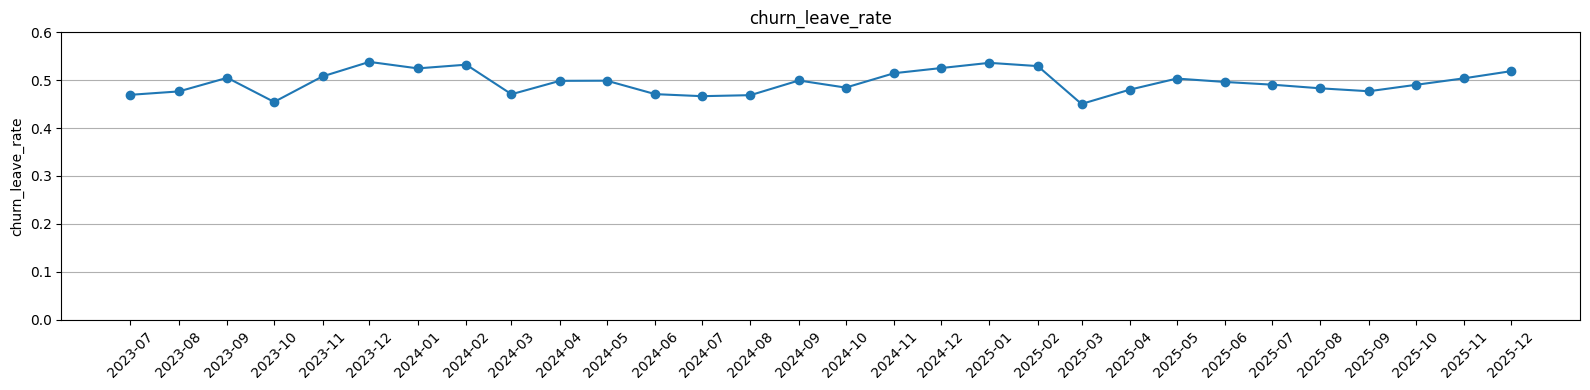

In [21]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(churn_leave_rate.index, churn_leave_rate.values, marker='o')

ax.set_title('churn_leave_rate')
ax.set_ylabel('churn_leave_rate')

ticks = pd.date_range(
    start=churn_leave_rate.index.min(),
    end=churn_leave_rate.index.max(),
    freq='MS'
)

ax.set_ylim(0, 0.6)

ax.set_xticks(ticks)
plt.grid(axis='y')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



## 3. Retention

### 3.1. Линейный

Продакт спрашивает помощи

> На какой вопрос отвечает эта метрика?


<img src="https://media.licdn.com/dms/image/v2/C5612AQHtKybfnmoRCA/article-cover_image-shrink_720_1280/article-cover_image-shrink_720_1280/0/1616135100626?e=1778112000&v=beta&t=G_Jp-8W5sB4gpvXcm8H0UooVkKkhzR4zewXvDZCVWnU" width="700">

зафиксировав начальный период и множество зарегистрированных из него пользователей, какая доля активна через X периодов?

---

Вы ответили слишком быстро. Вам прилетел follow up question:

> А это rolling или нет?


In [22]:
import numpy as np
import pandas as pd

# CURRENT_DATE = pd.Timestamp("2025-03-01")
CURRENT_DATE = pd.Timestamp("2023-06-01")

df = df_full.copy()

# для арифметики нужен тип period
df["cohort_month"] = df["registered_dttm"].dt.to_period("M")
df["session_month"] = df["session_start_dttm"].dt.to_period("M")

# когорта = пользователи, зарегистрированные в месяц CURRENT_DATE
current_cohort = CURRENT_DATE.to_period("M")
cohort_users = (
    df.loc[df["cohort_month"] == current_cohort, ["user_id", "cohort_month"]]
    .drop_duplicates() # Q: зачем нужно? A: аналогично оттоку, см. ## 2
)

# все активности этих пользователей
cohort_df = cohort_users.merge(
    df[["user_id", "session_month"]],
    on="user_id",
    how="left"
)

# номер месяца относительно регистрации
cohort_df["month_number"] = (
    cohort_df["session_month"] - cohort_df["cohort_month"] # Q: может ли быть < 0?
).apply(lambda x: x.n)

# размер когорты
cohort_size = cohort_users["user_id"].nunique()

# активные пользователи по месяцам жизни
retained = (
    cohort_df.groupby("month_number")["user_id"]
    .nunique()
    .sort_index()
)

retention = retained / cohort_size * 100

print(retention.head())

month_number
0    100.000000
1     53.687822
2     30.703259
3     23.499142
4     26.243568
Name: user_id, dtype: float64


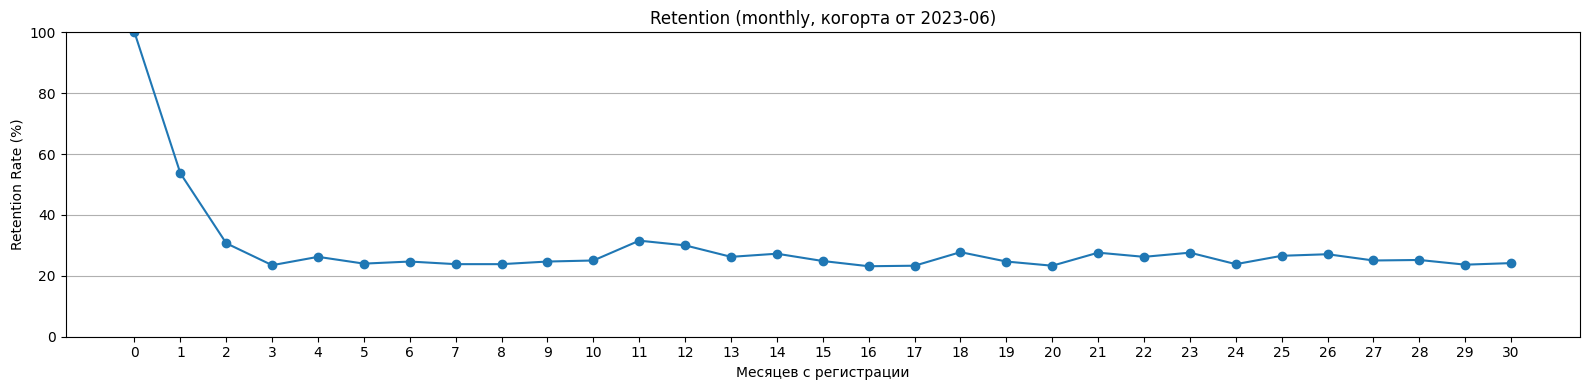

In [23]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(retention.index, retention.values, marker='o')

ax.set_title(f'Retention (monthly, когорта от {CURRENT_DATE.strftime('%Y-%m')})')
ax.set_xlabel('Месяцев с регистрации')
ax.set_ylabel('Retention Rate (%)')
plt.grid(axis='y')
ax.set_ylim(0, 100)
ax.set_xticks(retention.index)
plt.tight_layout()
plt.show()

# Q: какая доля пользователей составляет наше ядро? Как его определить?

А как превратить этот график в rolling? Можно ли просто cumsum?

<img src="https://miro.medium.com/1*kwN_Y8GNf2ZB6sNQxngVyw@2x.jpeg" width="300">

Cumsum нельзя, потому что посчитаются дважды те, кто проявил две активности в прошлые месяцы.

Если без гемора с джойнами - итеративно по месяцам

### 2.2. Heatmap

Снова вопрос от продакта

> Что находится в ячейке (i, j)?

<img src="https://i.sstatic.net/Dejo9.png" width="400">

Ячейка (i, j) - доля пользователей, зарегистрированных в период i и активных в период j

In [24]:
import seaborn as sns

# --- CONFIG ---
CURRENT_DATE = pd.Timestamp("2025-03-31")
N_MONTHS = 8

df = df[df['session_start_dttm'] < CURRENT_DATE]

# месяцы регистрации и активности
df["cohort_month"] = df["registered_dttm"].dt.to_period("M")
df["session_month"] = df["session_start_dttm"].dt.to_period("M")

current_cohort = CURRENT_DATE.to_period("M")

# берем N_MONTHS когорт: от CURRENT_DATE назад
cohort_range = pd.period_range(
    end=current_cohort,
    periods=N_MONTHS,
    freq="M"
)

# пользователи выбранных когорт
cohort_users = (
    df.loc[df["cohort_month"].isin(cohort_range), ["user_id", "cohort_month"]]
    .drop_duplicates()
)

# все активности этих пользователей
cohort_df = cohort_users.merge(
    df[["user_id", "session_month"]],
    on="user_id",
    how="left" # Q: почему right не подходит? A: см Linear retention
)

# номер месяца жизни пользователя
cohort_df["month_number"] = (
    cohort_df["session_month"] - cohort_df["cohort_month"]
).apply(lambda x: x.n if pd.notna(x) else np.nan)


# размеры когорт
cohort_sizes = (
    cohort_users.groupby("cohort_month")["user_id"]
    .nunique()
    .rename("cohort_size")
)

# активные пользователи по когортам и месяцам жизни
retained = (
    cohort_df.groupby(["cohort_month", "month_number"])["user_id"]
    .nunique()
    .rename("active_users")
    .reset_index()
)

# retention
retained = retained.merge(
    cohort_sizes.reset_index(),
    on="cohort_month",
    how="left"
)
retained["retention"] = retained["active_users"] / retained["cohort_size"]

# матрица retention
retention_matrix = retained.pivot(
    index="cohort_month",
    columns="month_number",
    values="retention"
)

# переименование строк и столбцов
retention_matrix = retention_matrix.reindex(index=cohort_range, columns=range(N_MONTHS))
print(retention_matrix)


month_number    0         1         2         3         4         5         6         7
2024-08       1.0  0.619792  0.328125  0.250000  0.239583  0.239583  0.203125  0.223958
2024-09       1.0  0.583333  0.305556  0.227778  0.244444  0.238889  0.255556       NaN
2024-10       1.0  0.546961  0.270718  0.220994  0.215470  0.287293       NaN       NaN
2024-11       1.0  0.547619  0.285714  0.214286  0.238095       NaN       NaN       NaN
2024-12       1.0  0.547170  0.245283  0.238994       NaN       NaN       NaN       NaN
2025-01       1.0  0.538961  0.370130       NaN       NaN       NaN       NaN       NaN
2025-02       1.0  0.576923       NaN       NaN       NaN       NaN       NaN       NaN
2025-03       1.0       NaN       NaN       NaN       NaN       NaN       NaN       NaN


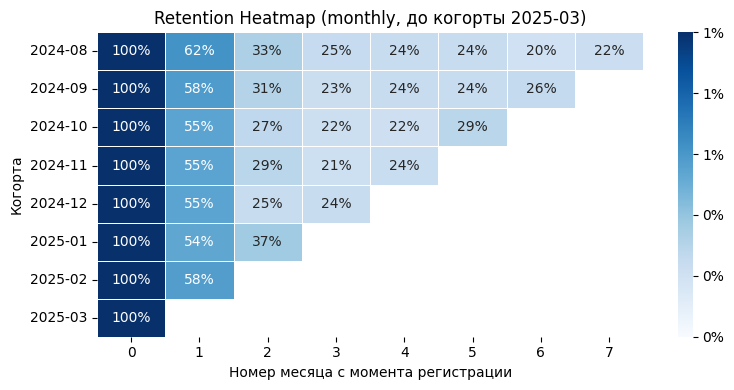

In [25]:
# аннотации в %
annot_data = retention_matrix.map(
    lambda x: f"{x:.0%}" if pd.notna(x) else ""
)

plt.figure(figsize=(8, 4))
sns.heatmap(
    retention_matrix,
    annot=annot_data,
    fmt="",
    cmap="Blues",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    mask=retention_matrix.isna(),
    cbar_kws={"format": "%.0f%%"}
)

plt.title(f"Retention Heatmap (monthly, до когорты {CURRENT_DATE.strftime('%Y-%m')})")
plt.xlabel("Номер месяца с момента регистрации")
plt.ylabel("Когорта")
plt.tight_layout()
plt.show()